<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/L06/cvar_cantileaver_exact_vs_sample_based.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CVaR-constrained design** - of a cantilever beam

We consider the design of a cantilever beam subject to an uncertain tip load $F$

**The GOAL:**

is to choose the smallest admissible beam stiffness (cheaper beam)while controlling the risk of excessive deflection.

### **Beam deflection model**

The tip deflection of a cantilever beam under load \(F\) is

$$
\delta(I,F)=\frac{F L^3}{3 E I},
$$

where:

* $L$: beam length  
* $E$: Young's modulus  
* $I$: second moment of area of the cross-section  
### **Violation function**

We define the violation function as

$$
g(I,F)=\delta(I,F)-\delta_{\max} = \\= \frac{F L^3}{3 E I} - -\delta_{\max} .
$$

* $\delta_{\max}$ denote the allowable maximum deflection
* $g(I,F)\le 0$: safe design  
* $g(I,F)>0$: violation of the deflection limit  

### **Chance-constrained formulation**

A reliability requirement can be written as a chance constraint

$$
\mathbb{P}\big(g(I,F)\le 0\big)\ge \beta,
$$

where $\beta \in (0,1)$ is the desired confidence level. A conservative approximation replaces the chance constraint with a CVaR constraint:

$$
\mathrm{CVaR}_{\beta}\big(g(I,F)\big)\le 0.
$$

# **The approximated CCP**

We seek the smallest beam stiffness satisfying the CVaR constraint:

$$
\begin{aligned}
\min_{I} \quad & I \\
\text{s.t.} \quad & \mathrm{CVaR}_{\beta}\big(g(I,F)\big)\le 0, \\
& I_{\min}\le I\le I_{\max}.
\end{aligned}
$$

This means that the design minimizes stiffness (or weight surrogate) while ensuring that the average of the worst deflection violations remains nonpositive.


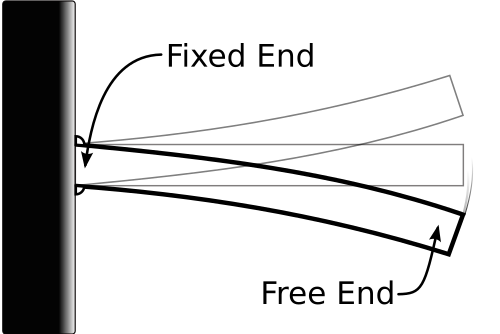

In [4]:
import numpy as np
import cvxpy as cp # package for convex optimization
from scipy.stats import norm
from scipy.optimize import minimize # scipy solver

# -----------------------------
# Problem data
L = 2.0 # length
E = 210e9 # elasticity
c = L**3 / (3.0 * E)
delta_max = 0.005 # max displacement
mu_F = 1000.0 # mean value force
sigma_F = 200.0 # standard deviation force
beta = 0.95 # chance constraint probability  1 -\alpha
I_min = 1e-8 # Min bounds on I
I_max = 5e-5 # Max bounds on I


### Exact Gaussian case
The force is known to be Gaussian distributed as follows:

$$
F\sim \mathcal N(\mu_F,\sigma_F^2),
$$

The function $g(I,F)\sim \mathcal N(\mu_g(I),\sigma_g^2(I))$ is therefore also Gaussian distributed.

The CVaR is:

$$ \mathrm{CVaR}_{\beta}(g) = \mu_g(I)+\sigma_g(I)\frac{\varphi(\Phi^{-1}(\beta))}{1-\beta},$$


Because the functional form is the following, $ g(I,F)= \frac{F L^3}{3 E I} - -\delta_{\max} $


Tthe transformed Gaussian parameters for $g$ are:

$$
\mu_g(I)=\frac{L^3}{3EI}\mu_F-\delta_{\max},
\qquad
\sigma_g(I)=\frac{L^3}{3EI}\sigma_F.
$$



The CCP program becomes:
 $$
\begin{aligned}
\min_{I} \quad & I \\
\text{subject to} \quad \\
&\mu_g(I)+\sigma_g(I)\frac{\varphi(\Phi^{-1}(\beta))}{1-\beta}\le 0,  \\
& I_{\min}\le I\le I_{\max}.
\end{aligned}
 $$






In [7]:
### --------- using a closed-form gaussian CVaR definition

def cvar_g(I):
    a = L**3 / (3.0 * E * I)
    mu = a * mu_F - delta_max
    sigma = a * sigma_F
    return mu + sigma * norm.pdf(norm.ppf(beta)) / (1.0 - beta)


# define the optimzation problem as follows:
res = minimize(
    fun=lambda x: x[0],
    x0=[1e-5], # initial guess
    bounds=[(I_min, I_max)],
    constraints=[{"type": "ineq", "fun": lambda x: -cvar_g(x[0])}],
    method="SLSQP"
)

print("I*   =", res.x[0])
print("CVaR =", cvar_g(res.x[0]))

I*   = 3.5874132623283254e-06
CVaR = -4.992907551163231e-09


In [6]:
from scipy.optimize import linprog
# Your params: L, E, mu_F, sigma_F, delta_max, beta, I_min, I_max
a = L**3 / (3.0 * E)
alpha = norm.ppf(beta)
k = norm.pdf(alpha) / (1 - beta)
c1 = a * (mu_F + k * sigma_F)

z_min = 1 / I_max
z_max = 1 / I_min

c = np.array([-1.0])  # Coefficients: max z
A_ub = np.array([[c1]])  # Shape (1,1): c1 * z <= delta_max
b_ub = np.array([delta_max])
bounds = [(z_min, z_max)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
z_star = res.x[0]
I_star = 1 / z_star
print("I* =", I_star)
print("CVaR =", cvar_g(I_star))  # ~0 if binding

I* = 3.587409680003772e-06
CVaR = 0.0


## Minimal sample-based CVaR approximation



---
Using $N$ sampled loads $F_1,\dots,F_N \sim \mathcal{N}(1000,200^2)$, the empirical CVaR constraint is approximated by:

$$
\widehat{\mathrm{CVaR}}_{\beta}(g)
=
\min_{\tau\in\mathbb R}
\left\{
\tau+\frac{1}{(1-\beta)N}\sum_{i=1}^N [g(I,F_i)-\tau]_+
\right\}.
$$

And our approximated problem is
 $$
\begin{aligned}
\min_{I} \quad & I \\
\text{subject to} \quad \\
&\min_{\tau\in\mathbb R}
\left\{
\eta+\frac{1}{(1-\beta)N}\sum_{i=1}^N [g(I,F_i)-\tau]_+
\right\} \le 0,  \\
& I_{\min}\le I\le I_{\max}.
\end{aligned}
 $$

---
We now introduce $N$ non-negative slack variables $s_i\ge 0$ and bring $\tau$ in the outer optimization. Thsi lead to a deterministic optimization problem:
$$\begin{aligned}
\min_{I,\tau,s_1,\dots,s_N} \quad & I \\
\text{s.t.} \quad
& \tau+\frac{1}{(1-\beta)N}\sum_{i=1}^N s_i \le 0, \\
& s_i \ge \frac{F_iL^3}{3EI}-\delta_{\max}-\tau \qquad i=1,\dots,N, \\
& s_i \ge 0, \qquad i=1,\dots,N, \\
& I_{\min}\le I\le I_{\max}.
\end{aligned}
$$

In [ ]:
### --------- using a samples-based approximation
rng = np.random.default_rng(42)
n_samples = 200
F = rng.normal(loc=1000.0, scale=200.0, size=n_samples)


# Decision variables
tau = cp.Variable(nonneg=True)          # tau = 1 / I
eta = cp.Variable()  # slack variable
s = cp.Variable(n_samples, nonneg=True) # slack variables, one for each sample

# Sampled violations
g = c * F * tau - delta_max

# Empirical CVaR constraint
constraints = [
    tau >= 1.0 / I_max,
    tau <= 1.0 / I_min,
    s >= g - eta,
    eta + cp.sum(s) / ((1.0 - beta) * n_samples) <= 0.0,
]

# Minimize I <=> maximize tau
problem = cp.Problem(cp.Maximize(tau), constraints)
problem.solve(solver=cp.CLARABEL, verbose=False)

tau_star = tau.value
I_star = 1.0 / tau_star

print("Status:", problem.status)
print("tau* =", tau_star)
print("I*   =", I_star)

# Check
g_star = c * F * tau_star - delta_max
p_safe = np.mean(g_star <= 0.0)
var_beta = np.quantile(g_star, beta)
cvar_beta = g_star[g_star >= var_beta].mean()

print("P[g <= 0] =", p_safe)
print("VaR =", var_beta)
print("CVaR =", cvar_beta)


Status: optimal
tau* = 298252.76317299536
I*   = 3.352860806255031e-06
P[g <= 0] = 0.96
VaR = -7.874832434830523e-05
CVaR = 0.00022954390668710752
